# ISLR — Chapter 2, Exercise 9: Exploratory Data Analysis on the Auto Dataset

Analysis of the Auto dataset from An Introduction to Statistical Learning (James et al.). The exercise covers variable classification (quantitative vs. qualitative), descriptive statistics (range, mean, standard deviation), the effect of subsetting on summary statistics, and graphical exploration of predictor relationships — with a focus on identifying variables useful for predicting fuel efficiency (mpg).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from re import template


auto = pd.read_csv('datasets/Auto.data', na_values=['?'], delim_whitespace = True)
auto


/var/folders/gq/kz8zkjwj6k1dr27f7byh1x_w0000gn/T/ipykernel_21323/407880169.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto = pd.read_csv('datasets/Auto.data', na_values=['?'], delim_whitespace = True)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


In [3]:
auto = auto.set_index('name')
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130.0,3504.0,12.0,70,1
buick skylark 320,15.0,8,350.0,165.0,3693.0,11.5,70,1
plymouth satellite,18.0,8,318.0,150.0,3436.0,11.0,70,1
amc rebel sst,16.0,8,304.0,150.0,3433.0,12.0,70,1
ford torino,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86.0,2790.0,15.6,82,1
vw pickup,44.0,4,97.0,52.0,2130.0,24.6,82,2
dodge rampage,32.0,4,135.0,84.0,2295.0,11.6,82,1


In [4]:

template = 'Column {0} contains {1} nan values'
for col in auto.columns:
    print(
        template.format(col,auto[col].isnull().sum())
    )
auto = auto.dropna()

Column mpg contains 0 nan values
Column cylinders contains 0 nan values
Column displacement contains 0 nan values
Column horsepower contains 5 nan values
Column weight contains 0 nan values
Column acceleration contains 0 nan values
Column year contains 0 nan values
Column origin contains 0 nan values


In [5]:
quantitative_cols = auto.select_dtypes(include='number')
print(quantitative_cols.columns)

for col in quantitative_cols.columns:
    print('col = {0}'.format(col))
    print('     max = {0} -- min {1}'.format(np.max(auto[col]),np.min(auto[col])))
    print('     mean = {0:.2f} -- STD = {1:.2f}'.format(auto[col].mean(),auto[col].std()))
    print('\n')



Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')
col = mpg
     max = 46.6 -- min 9.0
     mean = 23.45 -- STD = 7.81


col = cylinders
     max = 8 -- min 3
     mean = 5.47 -- STD = 1.71


col = displacement
     max = 455.0 -- min 68.0
     mean = 194.41 -- STD = 104.64


col = horsepower
     max = 230.0 -- min 46.0
     mean = 104.47 -- STD = 38.49


col = weight
     max = 5140.0 -- min 1613.0
     mean = 2977.58 -- STD = 849.40


col = acceleration
     max = 24.8 -- min 8.0
     mean = 15.54 -- STD = 2.76


col = year
     max = 82 -- min 70
     mean = 75.98 -- STD = 3.68


col = origin
     max = 3 -- min 1
     mean = 1.58 -- STD = 0.81




In [6]:
auto_dropped = auto.drop(auto.index[9:85])
auto_quant = auto_dropped.select_dtypes(include='number')
print('Mean: \n {0} \n'.format(auto_quant.mean()))
print('STD: \n {0} \n'.format(auto_quant.std()))
print('Range: \n {0} \n'.format(auto_quant.max() - auto_quant.min()))

Mean: 
 mpg               25.041637
cylinders          5.274021
displacement     179.373665
horsepower        98.715302
weight          2881.505338
acceleration      15.738790
year              77.508897
origin             1.633452
dtype: float64 

STD: 
 mpg               7.912874
cylinders         1.632155
displacement     95.512897
horsepower       33.822711
weight          792.548494
acceleration      2.570191
year              2.989403
origin            0.830760
dtype: float64 

Range: 
 mpg               35.6
cylinders          5.0
displacement     387.0
horsepower       184.0
weight          3197.0
acceleration      15.1
year              12.0
origin             2.0
dtype: float64 



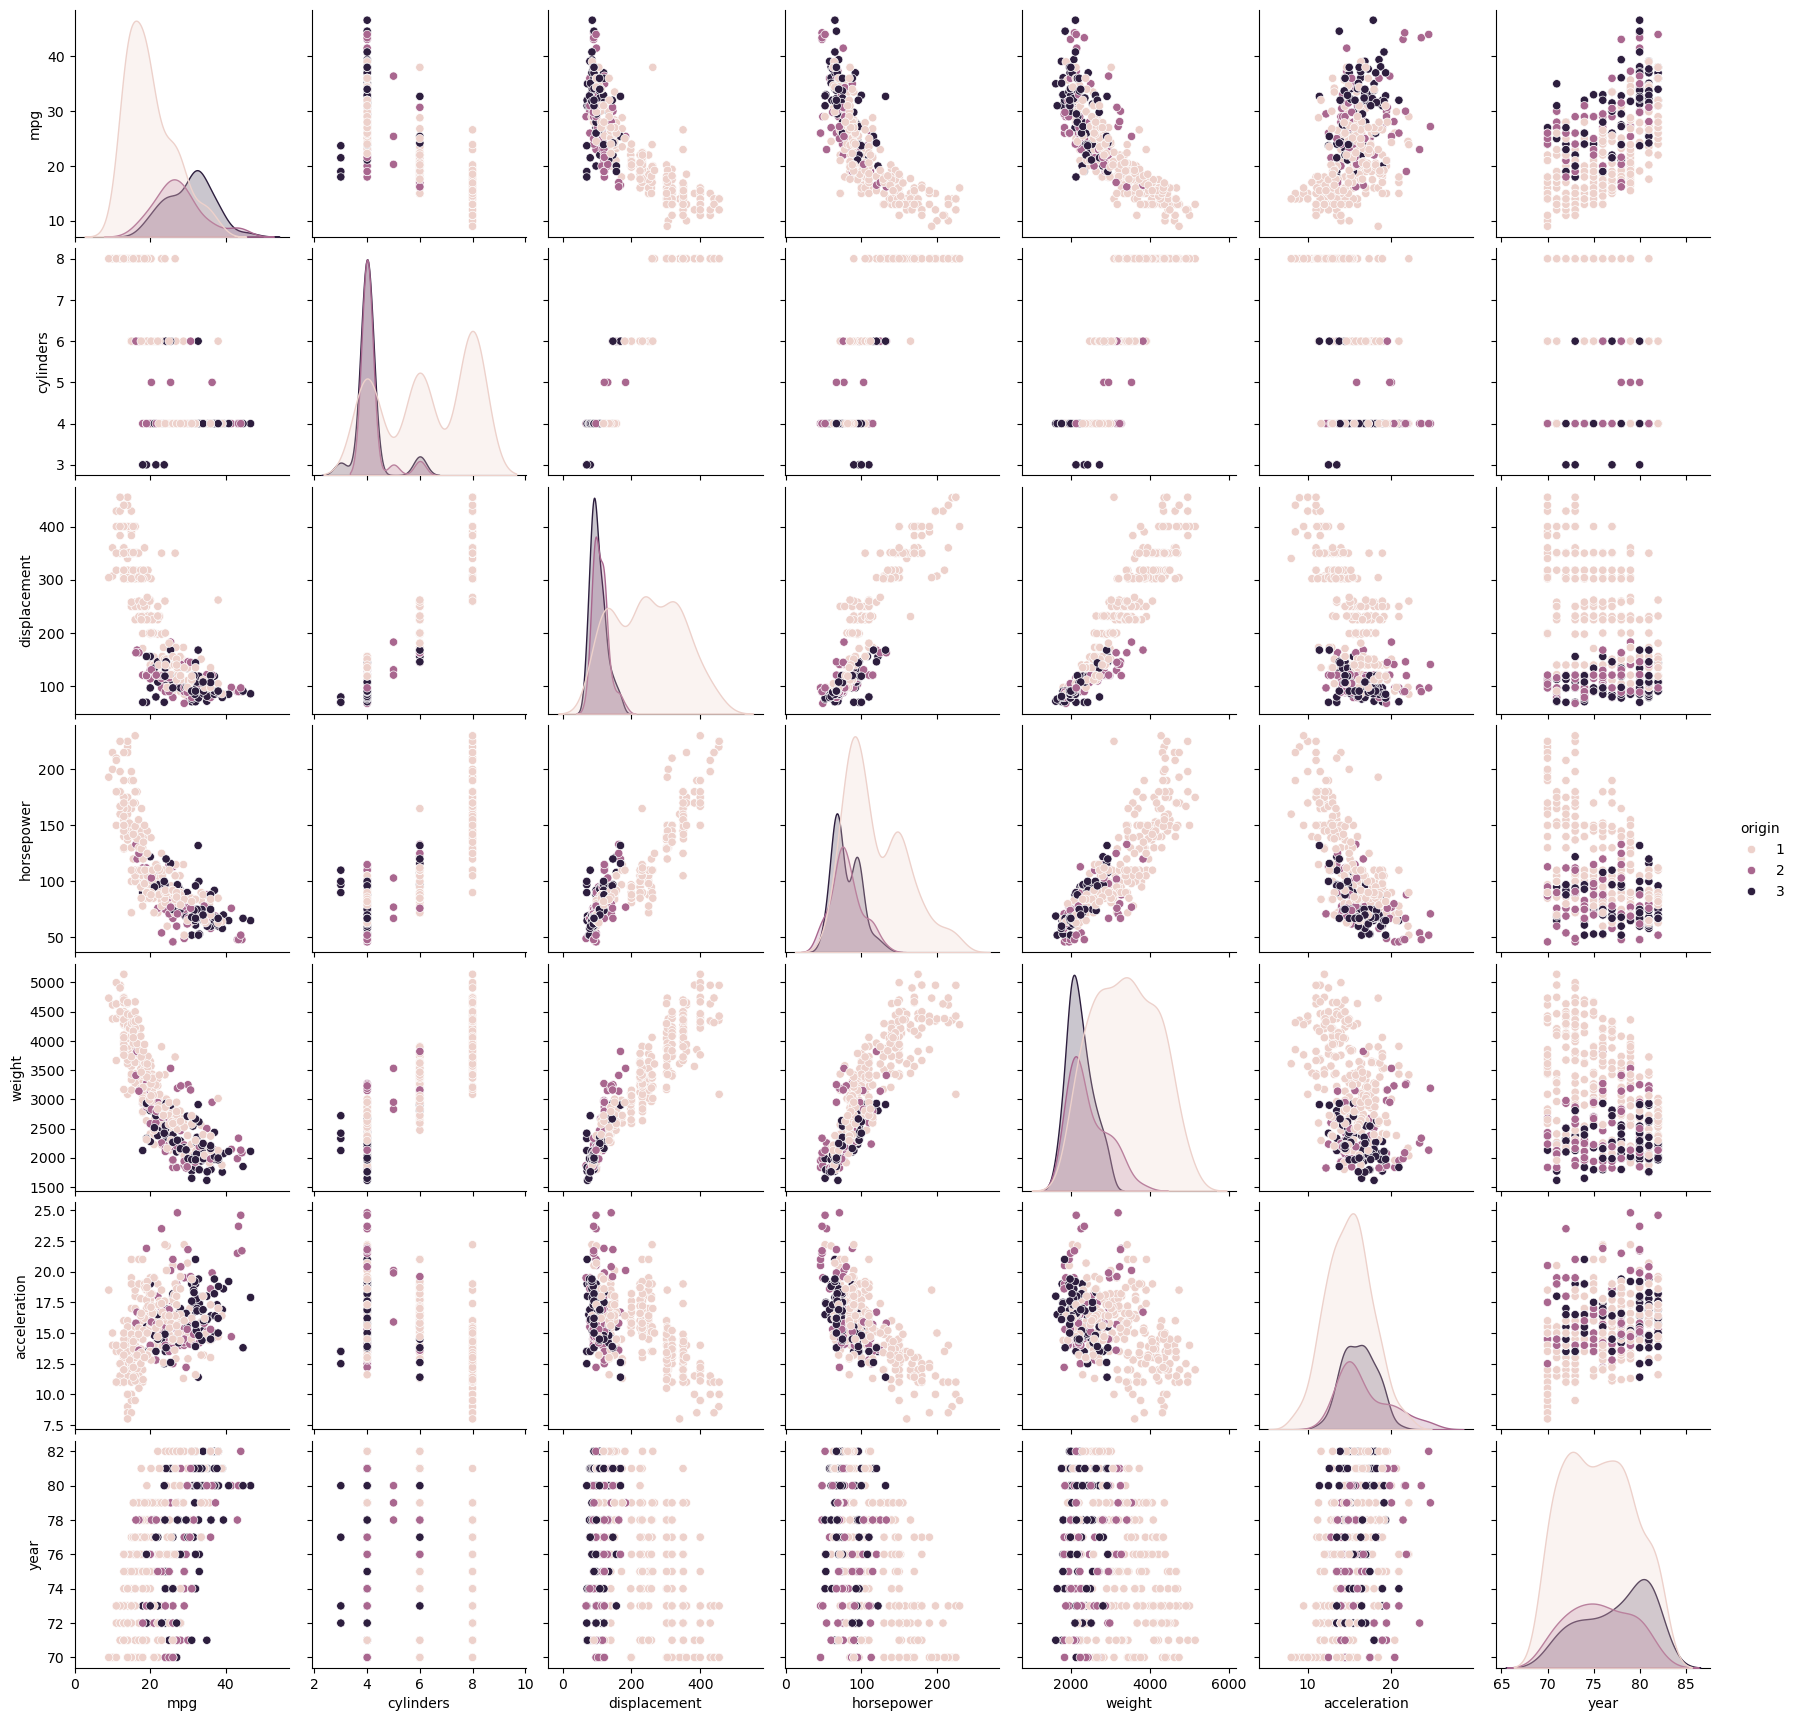

In [10]:
auto_tot_quant = auto.select_dtypes(include='number')
sns.pairplot(auto_tot_quant, hue='origin')

* American cars (origin 1) sit at one extreme on nearly every variable — heaviest, most powerful, least fuel-efficient. European and Japanese cars overlap at the other end.
* Many predictors (weight, displacement, horsepower, cylinders) are highly redundant — they move together.
* Key relationships like mpg vs weight are nonlinear, and mpg improves across all origins over time.
* Acceleration is the weakest discriminator among the variables.

(f) Suppose that we wish to predict gas mileage (mpg) on the basis
of the other variables. Do your plots suggest that any of the
other variables might be useful in predicting mpg? Justify your
answer.

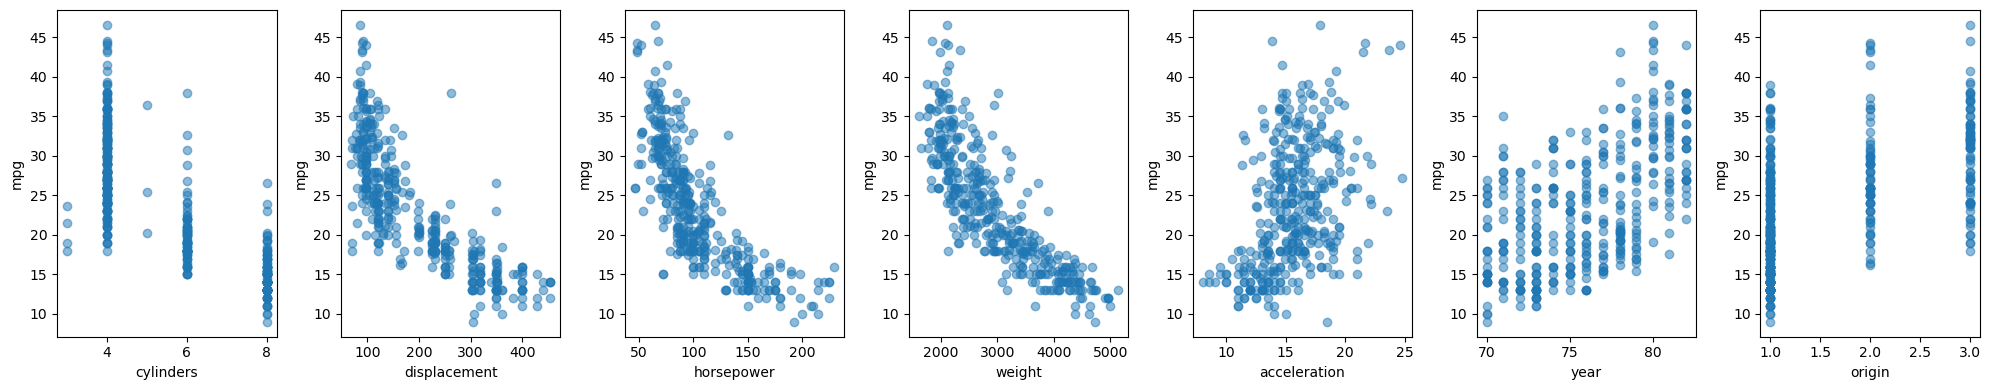

In [11]:
auto_num = auto.select_dtypes(include="number")
predictors = [col for col in auto_num.columns if col != "mpg"]

fig, axes = plt.subplots(1, len(predictors), figsize=(20, 4))
for i, col in enumerate(predictors):
    axes[i].scatter(auto[col], auto["mpg"], alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("mpg")
plt.tight_layout()
plt.show()

All variables show some association with mpg. Weight, displacement, horsepower, and cylinders are the strongest predictors (clear negative trends). Year is moderately useful (positive trend). Acceleration and origin are the weakest. Since the first four are highly correlated with each other, not all are needed in a model. However, to confirm these visual observations, one should test whether the correlations are statistically significant by checking the p-values of the correlation coefficients.